# HVSR peak robustness screen - other recording sessions

Run this notebook to check the other verified, sufficiently long individual-export sessions for a more defensible HVSR peak than the Terraza 28 session. It applies the same 384-profile sensitivity grid used in the Terraza 28 analysis, with spectral coverage from 0.2 to 50 Hz and peak search from 1 to 50 Hz.

To avoid duplicate evidence, daily-triplet exports are excluded because they overlap individual exports. Among eligible individual-export intervals, weighted interval scheduling selects a maximum-duration set with no temporal overlap. Sessions shorter than 10 minutes and Terraza 28 itself are excluded. Catalog location and sensor orientation are unverified; sessions must not be interpreted as independent sites without field records.

A candidate is marked defensible only if it passes reliability 3/3, clarity at least 5/6, complete f0/4-to-4*f0 frequency coverage, all four chronological blocks, and tracked-block peak deviation no greater than 10%. Peak amplitude alone does not determine the ranking. These sensitivity profiles use the same recording as the validation metrics and are exploratory, not independent confirmation.

In [1]:
from bisect import bisect_right
from pathlib import Path
import importlib.metadata
import json
import platform
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

WORKING_DIR = Path.cwd().resolve()
ROOT = next((folder for folder in (WORKING_DIR, *WORKING_DIR.parents)
             if (folder / 'utils/hvsr_tools.py').is_file() and (folder / 'data').is_dir()), None)
if ROOT is None:
    raise RuntimeError('Run from the repository root or main/02_processing.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from utils import hvsr_tools as hv

versions = {name: importlib.metadata.version(name)
            for name in ('hvsrpy', 'obspy', 'numpy', 'scipy', 'pandas', 'matplotlib')}
versions['python'] = platform.python_version()
print('Project root:', ROOT)
print('Versions:', versions)

Project root: /home/orincon/ciudad-perdida-hvsr
Versions: {'hvsrpy': '2.1.0', 'obspy': '1.5.1', 'numpy': '2.4.6', 'scipy': '1.17.1', 'pandas': '3.0.6', 'matplotlib': '3.11.2', 'python': '3.11.16'}


## 1. Build a non-overlapping session inventory

Only verified `individual_export` sessions are candidates. This avoids processing overlapping daily triplet exports as if they were distinct recordings. The weighted interval schedule maximizes the total catalog duration retained while ensuring that selected intervals do not overlap.

In [2]:
EXCLUDED_SESSION_ID = 'CBUCF_titanSMA_1614_20230519_213500_02'
MIN_SESSION_DURATION_S = 600.0
sessions = []
for manifest_path in sorted((ROOT / 'data/accelerometer').glob('20*/sessions.json')):
    manifest = json.loads(manifest_path.read_text())
    for item in manifest['sessions']:
        sessions.append({**item, 'manifest_path': str(manifest_path.relative_to(ROOT))})

inventory = pd.DataFrame(sessions)
if inventory.empty:
    raise RuntimeError('No catalog sessions were found under data/accelerometer/.')
inventory['selection_status'] = 'excluded: not a verified individual export'
individual = inventory['source_kind'].eq('individual_export')
verified = inventory['loader_status'].eq('verified')
inventory.loc[individual & ~verified, 'selection_status'] = 'excluded: loader not verified'
long_enough = pd.to_numeric(inventory['duration_s'], errors='coerce').ge(MIN_SESSION_DURATION_S)
inventory.loc[individual & verified & ~long_enough, 'selection_status'] = 'excluded: shorter than 10 minutes'
is_terraza = inventory['session_id'].eq(EXCLUDED_SESSION_ID)
inventory.loc[individual & verified & long_enough & is_terraza,
              'selection_status'] = 'excluded: Terraza 28 already analyzed'
eligible_mask = individual & verified & long_enough & ~is_terraza
eligible = inventory.loc[eligible_mask].copy()

if eligible.empty:
    raise RuntimeError('No eligible individual-export sessions remain after the duration and exclusion rules.')
eligible['_start'] = pd.to_datetime(eligible['starttime'], utc=True)
eligible['_end'] = pd.to_datetime(eligible['endtime'], utc=True)
eligible = eligible.sort_values(['_end', '_start', 'session_id']).reset_index(drop=True)
end_ns = eligible['_end'].astype('int64').to_numpy()
start_ns = eligible['_start'].astype('int64').to_numpy()
duration_s = pd.to_numeric(eligible['duration_s']).to_numpy(dtype=float)
predecessor = [bisect_right(end_ns, start_ns[i], hi=i) - 1 for i in range(len(eligible))]
best_duration = [0.0] * (len(eligible) + 1)
take_interval = [False] * (len(eligible) + 1)
for i in range(len(eligible)):
    include = duration_s[i] + best_duration[predecessor[i] + 1]
    exclude = best_duration[i]
    take_interval[i + 1] = include > exclude
    best_duration[i + 1] = max(include, exclude)

selected_indices = []
i = len(eligible)
while i > 0:
    if take_interval[i]:
        selected_indices.append(i - 1)
        i = predecessor[i - 1] + 1
    else:
        i -= 1
selected = eligible.iloc[sorted(selected_indices)].copy()
selected_ids = set(selected['session_id'])
inventory.loc[inventory['session_id'].isin(eligible['session_id']), 'selection_status'] = (
    'excluded: overlaps a longer-duration combination of sessions')
inventory.loc[inventory['session_id'].isin(selected_ids), 'selection_status'] = 'selected'
selected = selected.drop(columns=['_start', '_end']).reset_index(drop=True)

if selected.empty:
    raise RuntimeError('The non-overlap selection produced no sessions.')
print(f'Catalog sessions: {len(inventory)}; eligible before overlap removal: {len(eligible)}; '
      f'selected non-overlapping sessions: {len(selected)}; '
      f'total selected duration: {selected["duration_s"].sum() / 3600:.2f} hours')
display(selected[['session_id', 'date_utc', 'duration_s', 'starttime', 'endtime', 'input_files']])
display(inventory['selection_status'].value_counts().rename('sessions').to_frame())

Catalog sessions: 65; eligible before overlap removal: 19; selected non-overlapping sessions: 14; total selected duration: 5.42 hours


,session_id,date_utc,duration_s,starttime,endtime,input_files
0,CBUCF_titanSMA_1614_20230519_221100_01,2023-05-19,1389.450,2023-05-19T22:11:00.000000Z,2023-05-19T22:34:09.450000Z,[data/accelerometer/2023-05-19/CBUCF_titanSMA_...
1,CBUCF_titanSMA_1614_20230519_224800_01,2023-05-19,1540.600,2023-05-19T22:48:00.000000Z,2023-05-19T23:13:40.600000Z,[data/accelerometer/2023-05-19/CBUCF_titanSMA_...
2,CBUCF_titanSMA_1614_20230519_232900_01,2023-05-19,1596.240,2023-05-19T23:29:00.000000Z,2023-05-19T23:55:36.240000Z,[data/accelerometer/2023-05-19/CBUCF_titanSMA_...
3,CBUCF_titanSMA_1614_20230520_103800_02,2023-05-20,1349.685,2023-05-20T10:38:44.295000Z,2023-05-20T11:01:13.980000Z,[data/accelerometer/2023-05-20/CBUCF_titanSMA_...
4,CBUCF_titanSMA_1614_20230520_110900_01,2023-05-20,1397.450,2023-05-20T11:09:00.000000Z,2023-05-20T11:32:17.450000Z,[data/accelerometer/2023-05-20/CBUCF_titanSMA_...
5,CBUCF_titanSMA_1614_20230520_113700_01,2023-05-20,1264.450,2023-05-20T11:37:00.000000Z,2023-05-20T11:58:04.450000Z,[data/accelerometer/2023-05-20/CBUCF_titanSMA_...
6,CBUCF_titanSMA_1614_20230520_120239_02,2023-05-20,1394.190,2023-05-20T12:03:04.625000Z,2023-05-20T12:26:18.815000Z,[data/accelerometer/2023-05-20/CBUCF_titanSMA_...
7,CBUCF_titanSMA_1614_20230520_123500_02,2023-05-20,1355.420,2023-05-20T12:37:04.045000Z,2023-05-20T12:59:39.465000Z,[data/accelerometer/2023-05-20/CBUCF_titanSMA_...
8,CBUCF_titanSMA_1614_20230520_200700_03,2023-05-20,1379.385,2023-05-20T20:13:28.870000Z,2023-05-20T20:36:28.255000Z,[data/accelerometer/2023-05-20/CBUCF_titanSMA_...
9,CBUCF_titanSMA_1614_20230520_204400_01,2023-05-20,1359.165,2023-05-20T20:44:00.000000Z,2023-05-20T21:06:39.165000Z,[data/accelerometer/2023-05-20/CBUCF_titanSMA_...


,sessions
selection_status,
excluded: not a verified individual export,28
excluded: shorter than 10 minutes,17
selected,14
excluded: overlaps a longer-duration combination of sessions,5
excluded: Terraza 28 already analyzed,1


## 2. Define the matched analysis and candidate rule

Each session gets the same broad spectral band, peak search range, time-domain checks, and 384-profile parameter grid. A complete per-profile sweep is retained, including failures reported by the analysis helper.

In [3]:
BASE_PARAMS = hv.HVSRParams(
    window_length_s=30.0,
    overlap_pct=0.0,
    window_selection='continuous',
    anti_trigger=True,
    sta_s=2.0,
    lta_s=30.0,
    sta_lta_min=0.1,
    sta_lta_max=3.0,
    sta_lta_method='vector',
    sta_lta_amplitude='abs',
    transient_padding_s=2.0,
    max_crest_factor=20.0,
    filter_corners_hz=(None, None),
    detrend='linear',
    taper_pct_per_side=5.0,
    smoothing='konno_and_ohmachi',
    smoothing_bandwidth=40.0,
    horizontal_combination='squared_average',
    fmin=0.2,
    fmax=50.0,
    n_frequencies=900,
    frequency_spacing='log',
    peak_range_hz=(1.0, 50.0),
    frequency_domain_rejection=True,
    fdr_n=2.5,
)
PARAMETER_GRID = {
    'window_length_s': (15.0, 20.0, 30.0, 40.0),
    'anti_trigger': (False, True),
    'max_crest_factor': (None, 15.0, 20.0),
    'detrend': ('constant', 'linear'),
    'smoothing_bandwidth': (20.0, 40.0),
    'horizontal_combination': ('geometric_mean', 'squared_average'),
    'frequency_domain_rejection': (False, True),
}
EXPECTED_PROFILES = int(np.prod([len(values) for values in PARAMETER_GRID.values()]))
DEFENSIBILITY_RULE = (
    'reliability 3/3; clarity >=5/6; full f0/4-to-4*f0 coverage; '
    'four complete time blocks; tracked block peak deviation <=10%'
)
print(f'{EXPECTED_PROFILES} profiles per session; defensibility rule: {DEFENSIBILITY_RULE}')

384 profiles per session; defensibility rule: reliability 3/3; clarity >=5/6; full f0/4-to-4*f0 coverage; four complete time blocks; tracked block peak deviation <=10%


## 3. Process sessions and run sensitivity sweeps

A failed session is not silently dropped: its exception type and message are written to the session summary. Candidate profiles are ranked by defensibility, clarity, block stability, and only then amplitude.

In [4]:
session_summaries = []
sweep_tables = []
for _, session in selected.iterrows():
    session_id = session['session_id']
    print(f'Analyzing {session_id} ({session["duration_s"] / 60:.1f} min)...')
    try:
        input_files = [ROOT / path for path in session['input_files']]
        record = hv.load_record(input_files, starttime=session['starttime'], endtime=session['endtime'])
        record.meta.update(session_id=session_id, site_label=session.get('physical_site', 'unknown'),
                           site_label_source='catalog; physical site not verified')
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            sweep = hv.parameter_sweep(record, BASE_PARAMS, PARAMETER_GRID, time_blocks=4)
        sweep.insert(0, 'session_id', session_id)
        sweep.insert(1, 'date_utc', session['date_utc'])
        sweep_tables.append(sweep)
        successful = sweep.loc[sweep['error'].isna()].copy() if 'error' in sweep else sweep.copy()
        if successful.empty:
            session_summaries.append({
                'session_id': session_id, 'date_utc': session['date_utc'],
                'duration_s': float(session['duration_s']), 'status': 'no successful profiles',
                'n_profiles': len(sweep), 'error': 'All parameter profiles failed; see sweep export.',
            })
            continue
        successful['defensible_candidate'] = (
            successful['reliability_count'].eq(3)
            & successful['clarity_count'].ge(5)
            & successful['frequency_coverage_complete']
            & successful['time_blocks_complete']
            & successful['block_tracked_max_deviation_pct'].le(10)
        )
        ranked = successful.sort_values(
            ['defensible_candidate', 'clarity_count', 'block_tracked_max_deviation_pct', 'A0_mean_curve'],
            ascending=[False, False, True, False],
        )
        best = ranked.iloc[0]
        summary = {
            'session_id': session_id,
            'date_utc': session['date_utc'],
            'duration_s': float(session['duration_s']),
            'status': 'analyzed',
            'n_profiles': int(len(sweep)),
            'n_successful_profiles': int(len(successful)),
            'n_defensible_profiles': int(successful['defensible_candidate'].sum()),
            'n_profiles_A0_ge_2': int(successful['A0_mean_curve'].ge(2.0).sum()),
            'f0_hz': float(best['f0_mean_curve_hz']),
            'A0': float(best['A0_mean_curve']),
            'reliability_count': int(best['reliability_count']),
            'clarity_count': int(best['clarity_count']),
            'frequency_coverage_complete': bool(best['frequency_coverage_complete']),
            'time_blocks_complete': bool(best['time_blocks_complete']),
            'block_tracked_max_deviation_pct': float(best['block_tracked_max_deviation_pct']),
            'defensible_candidate': bool(best['defensible_candidate']),
            'best_window_length_s': float(best['window_length_s']),
            'best_anti_trigger': bool(best['anti_trigger']),
            'best_max_crest_factor': None if pd.isna(best['max_crest_factor']) else float(best['max_crest_factor']),
            'best_detrend': best['detrend'],
            'best_smoothing_bandwidth': float(best['smoothing_bandwidth']),
            'best_horizontal_combination': best['horizontal_combination'],
            'best_frequency_domain_rejection': bool(best['frequency_domain_rejection']),
            'error': None,
        }
        session_summaries.append(summary)
        print(f"  best: f0={summary['f0_hz']:.3f} Hz, A0={summary['A0']:.3f}, "
              f"clarity={summary['clarity_count']}/6, defensible={summary['defensible_candidate']}")
    except Exception as error:
        session_summaries.append({
            'session_id': session_id, 'date_utc': session['date_utc'],
            'duration_s': float(session['duration_s']), 'status': 'session failed',
            'n_profiles': 0, 'error': f'{type(error).__name__}: {error}',
        })
        print(f'  FAILED: {type(error).__name__}: {error}')

summary_table = pd.DataFrame(session_summaries)
all_sweeps = pd.concat(sweep_tables, ignore_index=True) if sweep_tables else pd.DataFrame()
if summary_table.empty:
    raise RuntimeError('No session results were produced; inspect the session inventory and inputs.')
display(summary_table.sort_values(
    ['defensible_candidate', 'clarity_count', 'block_tracked_max_deviation_pct', 'A0'],
    ascending=[False, False, True, False], na_position='last'))

Analyzing CBUCF_titanSMA_1614_20230519_221100_01 (23.2 min)...
  best: f0=14.639 Hz, A0=1.335, clarity=5/6, defensible=False
Analyzing CBUCF_titanSMA_1614_20230519_224800_01 (25.7 min)...
  best: f0=47.311 Hz, A0=2.943, clarity=5/6, defensible=False
Analyzing CBUCF_titanSMA_1614_20230519_232900_01 (26.6 min)...
  best: f0=1.209 Hz, A0=1.362, clarity=4/6, defensible=False
Analyzing CBUCF_titanSMA_1614_20230520_103800_02 (22.5 min)...
  best: f0=11.450 Hz, A0=0.798, clarity=3/6, defensible=False
Analyzing CBUCF_titanSMA_1614_20230520_110900_01 (23.3 min)...
  best: f0=2.574 Hz, A0=0.886, clarity=3/6, defensible=False
Analyzing CBUCF_titanSMA_1614_20230520_113700_01 (21.1 min)...
  best: f0=14.911 Hz, A0=0.871, clarity=4/6, defensible=False
Analyzing CBUCF_titanSMA_1614_20230520_120239_02 (23.2 min)...
  best: f0=23.635 Hz, A0=2.067, clarity=5/6, defensible=False
Analyzing CBUCF_titanSMA_1614_20230520_123500_02 (22.6 min)...
  best: f0=18.487 Hz, A0=1.292, clarity=4/6, defensible=False
An

,session_id,date_utc,duration_s,status,n_profiles,n_successful_profiles,n_defensible_profiles,n_profiles_A0_ge_2,f0_hz,A0,...,block_tracked_max_deviation_pct,defensible_candidate,best_window_length_s,best_anti_trigger,best_max_crest_factor,best_detrend,best_smoothing_bandwidth,best_horizontal_combination,best_frequency_domain_rejection,error
6,CBUCF_titanSMA_1614_20230520_120239_02,2023-05-20,1394.190,analyzed,384,384,0,20,23.634931,2.067382,...,3.617996,False,40.0,False,20.0,linear,40.0,squared_average,False,None
9,CBUCF_titanSMA_1614_20230520_204400_01,2023-05-20,1359.165,analyzed,384,384,0,29,1.137333,2.425829,...,3.753809,False,15.0,False,15.0,constant,20.0,squared_average,True,None
1,CBUCF_titanSMA_1614_20230519_224800_01,2023-05-19,1540.600,analyzed,384,384,0,192,47.311196,2.942754,...,7.105093,False,30.0,False,15.0,linear,20.0,squared_average,True,None
13,CBUCF_titanSMA_1614_20230522_202000_01,2023-05-22,1259.995,analyzed,384,384,0,20,1.050055,3.511191,...,115.485319,False,15.0,False,15.0,constant,40.0,squared_average,True,None
0,CBUCF_titanSMA_1614_20230519_221100_01,2023-05-19,1389.450,analyzed,384,384,0,0,14.638673,1.335130,...,inf,False,40.0,True,20.0,linear,20.0,squared_average,True,None
5,CBUCF_titanSMA_1614_20230520_113700_01,2023-05-20,1264.450,analyzed,384,384,0,0,14.910896,0.870794,...,1.220843,False,30.0,False,20.0,linear,20.0,geometric_mean,False,None
2,CBUCF_titanSMA_1614_20230519_232900_01,2023-05-19,1596.240,analyzed,384,384,0,0,1.209375,1.362242,...,1.825663,False,15.0,False,NaN,constant,20.0,geometric_mean,True,None
7,CBUCF_titanSMA_1614_20230520_123500_02,2023-05-20,1355.420,analyzed,384,384,0,0,18.486755,1.291631,...,3.617996,False,40.0,False,NaN,constant,40.0,geometric_mean,False,None
8,CBUCF_titanSMA_1614_20230520_200700_03,2023-05-20,1379.385,analyzed,384,384,0,0,16.150247,1.040402,...,0.000000,False,20.0,True,15.0,linear,40.0,geometric_mean,False,None
11,CBUCF_titanSMA_1614_20230522_191559_02,2023-05-22,1254.880,analyzed,384,384,0,0,12.632390,0.977799,...,1.825663,False,15.0,True,20.0,linear,40.0,geometric_mean,False,None


## 4. Compare results and export

The plot shows each session's top-ranked profile. A0 = 2 is shown as an amplitude reference only; crossing it does not by itself make a peak defensible. The full profile grid and session-selection inventory are exported for auditability.

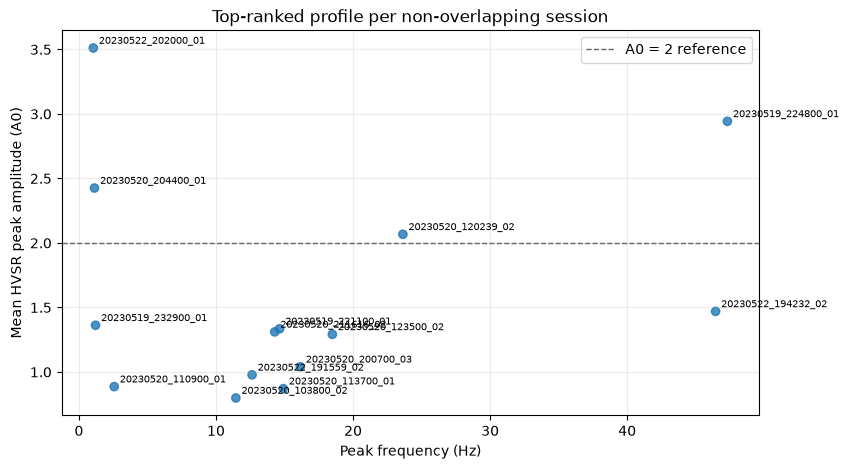

Saved summary: /home/orincon/ciudad-perdida-hvsr/outputs/other_sessions_peak_screen/session_peak_summary.csv
Saved all parameter profiles: /home/orincon/ciudad-perdida-hvsr/outputs/other_sessions_peak_screen/session_robustness_sweeps.csv
Saved session inventory: /home/orincon/ciudad-perdida-hvsr/outputs/other_sessions_peak_screen/session_inventory.csv
Defensible sessions: 0


In [5]:
analyzed = summary_table.loc[summary_table['status'].eq('analyzed')].copy()
if analyzed.empty:
    print('No sessions were successfully analyzed; review the error column and session inventory.')
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    colors = np.where(analyzed['defensible_candidate'].fillna(False), 'tab:green', 'tab:blue')
    ax.scatter(analyzed['f0_hz'], analyzed['A0'], c=colors, alpha=0.8)
    for _, row in analyzed.iterrows():
        ax.annotate(row['session_id'].replace('CBUCF_titanSMA_1614_', ''),
                    (row['f0_hz'], row['A0']), xytext=(4, 3),
                    textcoords='offset points', fontsize=7)
    ax.axhline(2.0, color='0.4', linestyle='--', linewidth=1, label='A0 = 2 reference')
    ax.set(xlabel='Peak frequency (Hz)', ylabel='Mean HVSR peak amplitude (A0)',
           title='Top-ranked profile per non-overlapping session')
    ax.grid(True, alpha=0.25)
    ax.legend()
    plt.show()

OUTPUT_DIR = ROOT / 'outputs/other_sessions_peak_screen'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
summary_path = OUTPUT_DIR / 'session_peak_summary.csv'
sweep_path = OUTPUT_DIR / 'session_robustness_sweeps.csv'
inventory_path = OUTPUT_DIR / 'session_inventory.csv'
summary_table.to_csv(summary_path, index=False)
if not all_sweeps.empty:
    all_sweeps.to_csv(sweep_path, index=False)
inventory.to_csv(inventory_path, index=False)
print('Saved summary:', summary_path)
print('Saved all parameter profiles:', sweep_path if not all_sweeps.empty else 'no successful sweeps')
print('Saved session inventory:', inventory_path)
print('Defensible sessions:', int(analyzed['defensible_candidate'].fillna(False).sum()) if not analyzed.empty else 0)